/tmp/ipython-input-2813977771.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="2y")
[*********************100%***********************]  1 of 1 completed


First 5 rows of data:
Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2023-12-18  1251.239014  1258.137903  1236.324379  1238.632370    14165188
2023-12-19  1269.652710  1277.494571  1253.323497  1268.114050    16820604
2023-12-20  1254.291382  1289.878086  1250.742696  1276.080186    17736722
2023-12-21  1271.861450  1277.296201  1249.874163  1254.217020    13765454
2023-12-22  1273.102173  1280.968874  1264.466020  1270.397218    16541784

Last 5 rows with indicators:
Price             Close         High          Low         Open      Volume  \
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS   
Date                                                                         
2025-12-11  1545.000000  1550.000000  1524.000000  1536.900024     4706197   
2025-12-12  1556.500000  1559.800049

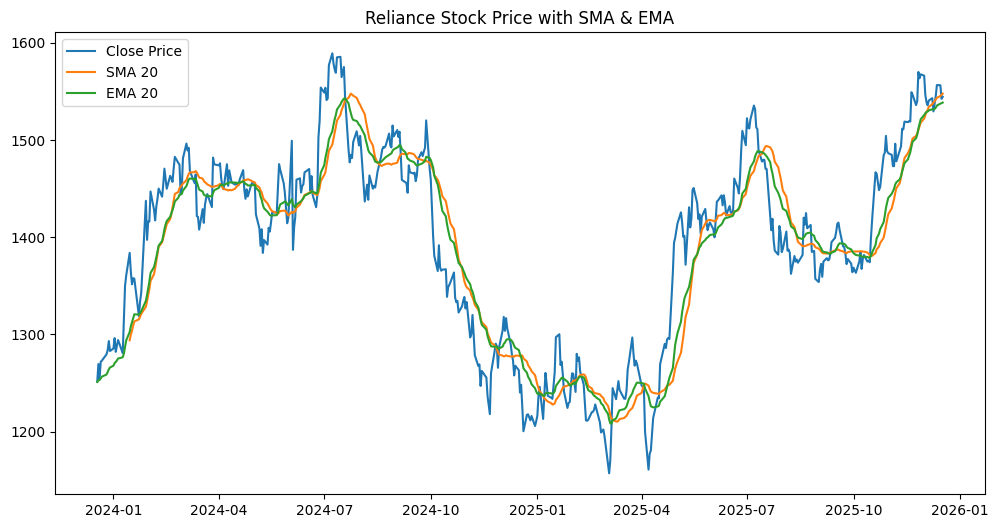

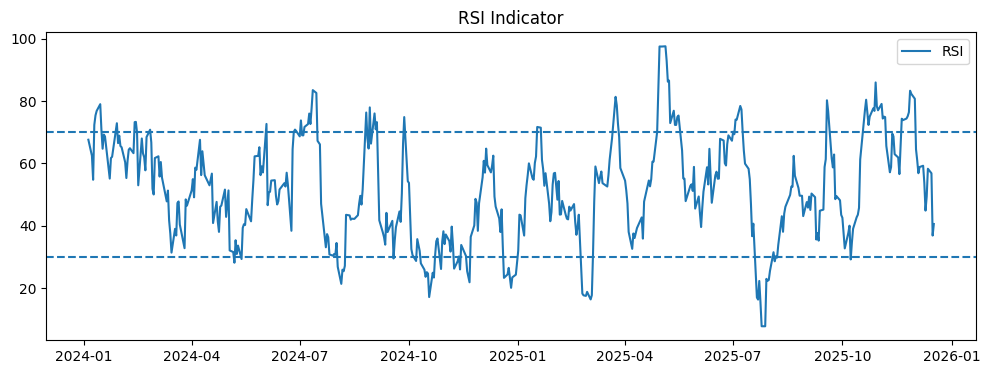

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


ticker = "RELIANCE.NS"
data = yf.download(ticker, period="2y")

print("First 5 rows of data:")
print(data.head())


def SMA(series, window):
    return series.rolling(window=window).mean()

def EMA(series, window):
    return series.ewm(span=window, adjust=False).mean()


def RSI(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def MACD(series, fast=12, slow=26, signal=9):
    ema_fast = EMA(series, fast)
    ema_slow = EMA(series, slow)
    macd = ema_fast - ema_slow
    signal_line = EMA(macd, signal)
    return macd, signal_line


def Bollinger_Bands(series, window=20):
    sma = SMA(series, window)
    std = series.rolling(window).std()
    upper = sma + 2 * std
    lower = sma - 2 * std
    return upper, lower


def Stochastic_Oscillator(high, low, close, window=14):
    lowest_low = low.rolling(window).min()
    highest_high = high.rolling(window).max()
    return 100 * (close - lowest_low) / (highest_high - lowest_low)


data["SMA_20"] = SMA(data["Close"], 20)
data["EMA_20"] = EMA(data["Close"], 20)
data["RSI"] = RSI(data["Close"])
data["MACD"], data["MACD_Signal"] = MACD(data["Close"])
data["BB_Upper"], data["BB_Lower"] = Bollinger_Bands(data["Close"])
data["Stochastic"] = Stochastic_Oscillator(data["High"], data["Low"], data["Close"])

print("\nLast 5 rows with indicators:")
print(data.tail())


plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Close Price")
plt.plot(data["SMA_20"], label="SMA 20")
plt.plot(data["EMA_20"], label="EMA 20")
plt.legend()
plt.title("Reliance Stock Price with SMA & EMA")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(data["RSI"], label="RSI")
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.legend()
plt.title("RSI Indicator")
plt.show()
